## Analysis Distance Distribution

In [1]:
from __future__ import annotations
from pymatgen.core import Structure
import matplotlib.pyplot as plt
import numpy as np

In [26]:
def compute_rdf(
    structure: Structure,
    atom_index: int | None = None, 
    r_max: float = 12.0,
    dr: float = 0.1
):
    """Function to compute radial distribution function (rdf) of a 
    given atom in a structure.
    
    Args:
        structure (Structure): pymatgen structure object.
        atom_index (int): Index of atom in the structure. If None, rdf 
            of all atoms is computed.
            Default: None.
        r_max (float): Maximum distance to compute rdf.
            Default: 10.0 Angstrom.
        dr (float): Step size for computing rdf.
            Default: 0.1 Angstrom.
    
    Returns:
        r (list): List of distances.
        rdf (list): List of rdf values.
    """
    # Check r_max smaller than cell length
    if 2 * r_max > min(structure.lattice.abc):
        # Make supercell
        factor = int(2 * r_max / min(structure.lattice.abc)) + 1
        structure.make_supercell(factor)
    
    # Compute distances for every atoms considering pbc
    dist_matrix = structure.distance_matrix
    
    if atom_index is not None:
        dist = dist_matrix[atom_index]

        # Remove zores
        dist = dist[dist != 0]
        rdf, r = np.histogram(dist, bins=np.arange(0, r_max + dr, dr))
        r = (r[1:] + r[:-1]) / 2
        # Normalize w.r.t. ave density
        rdf = rdf / (sum(rdf) / (4 * np.pi * r_max**3 / 3))
        # Normalize over dr 
        rdf = rdf / (2 * 4 * np.pi * r**2 * dr)

    else:
        dist = dist_matrix.flatten()
        # Remove zores
        dist = dist[dist != 0]
        rdf, r = np.histogram(dist, bins=np.arange(0, r_max + dr, dr))
        r = (r[1:] + r[:-1]) / 2
        rdf = rdf / (sum(rdf) / (4 * np.pi * r_max**3 / 3))
        rdf = rdf / (4 * np.pi * r**2 * dr)
    
    return rdf, r        

### Compute Pair Distribution Function (PDF)

In [27]:
# Load original structure without diffusion
s_ori = Structure.from_file(
    filename = "../data/distance/structure_ori.cif",
    site_tolerance=0,
    frac_tolerance=0,
)

# Load reinpainted structure with diffusion
s_0 = Structure.from_file(
    filename = "../data/distance/structure_0_0.cif",
    site_tolerance=0,
    frac_tolerance=0,
)

In [4]:
# Get atom_index for center atom
threshold = 1e-6  
distances = np.linalg.norm(s_ori.frac_coords - np.array([[0.5, 0.5, 0.5]]), axis=1)
atom_index = np.where(distances < threshold)[0][0]

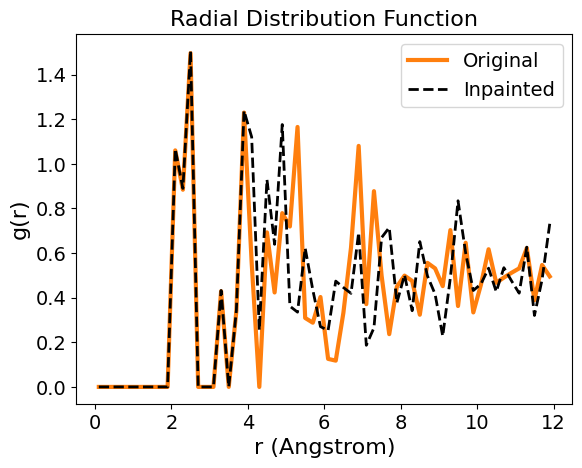

In [5]:
# Compute rdf for structure
g_r_ori, radii_ori = compute_rdf(s_ori, atom_index, dr=0.2)
g_r_0, radii_0 = compute_rdf(s_0, atom_index, dr=0.2)

# Plot
plt.plot(radii_ori, g_r_ori, 'C1-', lw=3, label='Original', alpha=1)
plt.plot(radii_0, g_r_0, 'k--', lw=2, label='Inpainted', alpha=1)
plt.xlabel("r (Angstrom)", fontsize=16)
plt.ylabel("g(r)", fontsize=16)
plt.title("Radial Distribution Function", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14)

### Compute Histogram of  Outer Shell Distance

In [53]:
# Load original structure without diffusion
s_ori = Structure.from_file(
    filename = "../data/distance/structure_ori.cif",
    site_tolerance=0,
    frac_tolerance=0,
)


In [54]:
# Get the indices for atoms in outer shell
cut_threshold = 5
frac_coords_0 = s_ori.frac_coords
center = np.array([0.5, 0.5, 0.5])
frac_dists = frac_coords_0 - center[None, :]
cart_dists = np.array(s_0.lattice.lengths)[None, :] * frac_dists
cart_dist_ori = np.linalg.norm(cart_dists, axis = 1)
diff_indices = np.where(cart_dist_ori > cut_threshold)[0]

In [55]:
num_samples = 100

# Load reinpainted structure with diffusion
s_list = []
for i in range(num_samples):
    s_0 = Structure.from_file(
        filename = f"../data/distance/structure_{i}_0.cif",
        site_tolerance=0,
        frac_tolerance=0,
    )
    s_list.append(s_0)

In [58]:
cart_dist_diff_list = []

for i in range(num_samples):
    # Compute the distance from current atom to the center of the cell
    frac_coords_0 = s_0.frac_coords
    center = np.array([0.5, 0.5, 0.5])
    frac_dists = frac_coords_0 - center[None, :]
    cart_dists = np.array(s_0.lattice.lengths)[None, :] * frac_dists
    cart_dist_0 = np.linalg.norm(cart_dists, axis = 1)
    cart_dist_diff_list.append(cart_dist_0[diff_indices])

cart_dist_diff_list = np.concatenate(cart_dist_diff_list)

In [68]:
dr = 0.1

rdf_ori, r_ori = np.histogram(cart_dist_ori[diff_indices], bins=np.arange(0, 10, dr))
r_ori = (r_ori[1:] + r_ori[:-1]) / 2

rdf_inpaint, r_inpaint = np.histogram(cart_dist_diff_list, bins=np.arange(0, 10, dr))
r_inpaint = (r_inpaint[1:] + r_inpaint[:-1]) / 2

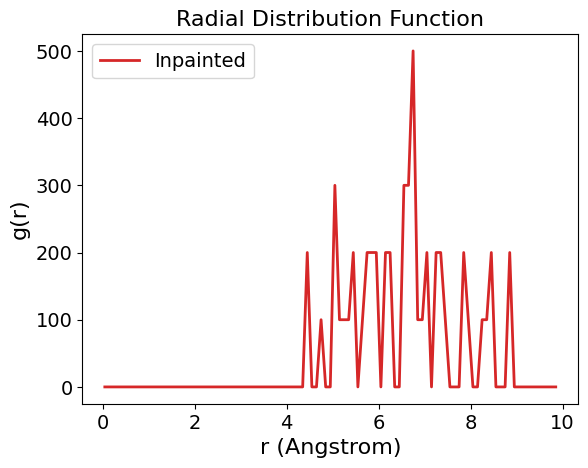

In [76]:
# Plot
# plt.plot(r_ori,rdf_ori*100, 'C1-', lw=3, label='Original')
plt.plot(r_inpaint, rdf_inpaint, 'C3-', lw=2, label='Inpainted')
plt.xlabel("r (Angstrom)", fontsize=16)
plt.ylabel("g(r)", fontsize=16)
plt.title("Radial Distribution Function", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14)